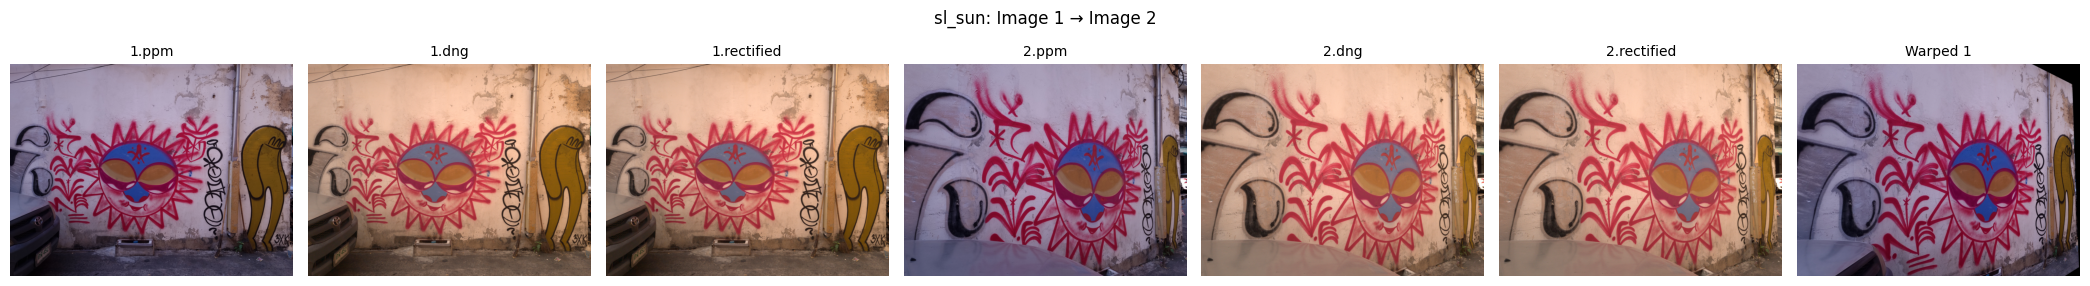

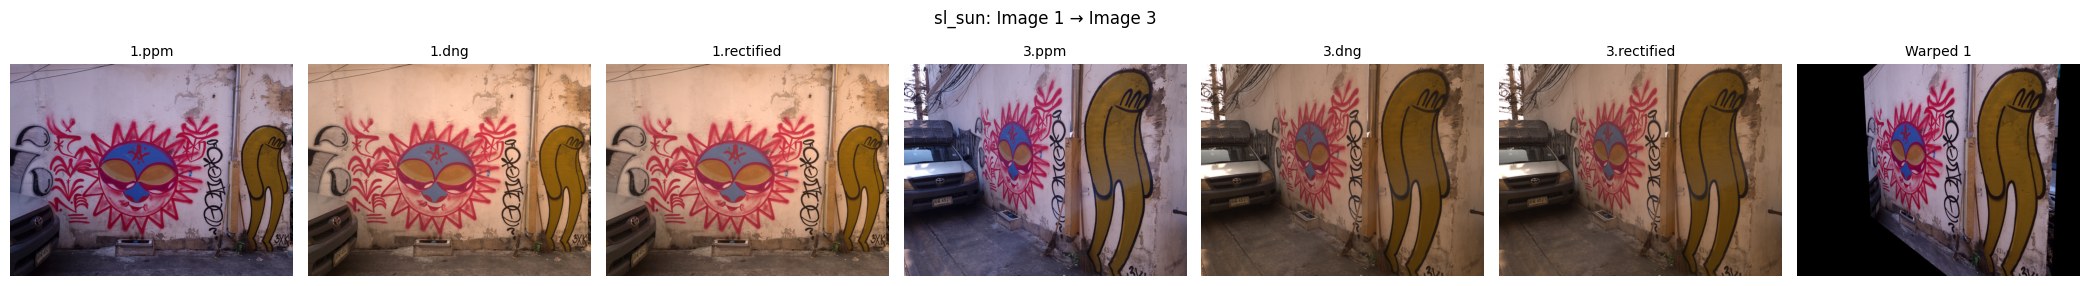

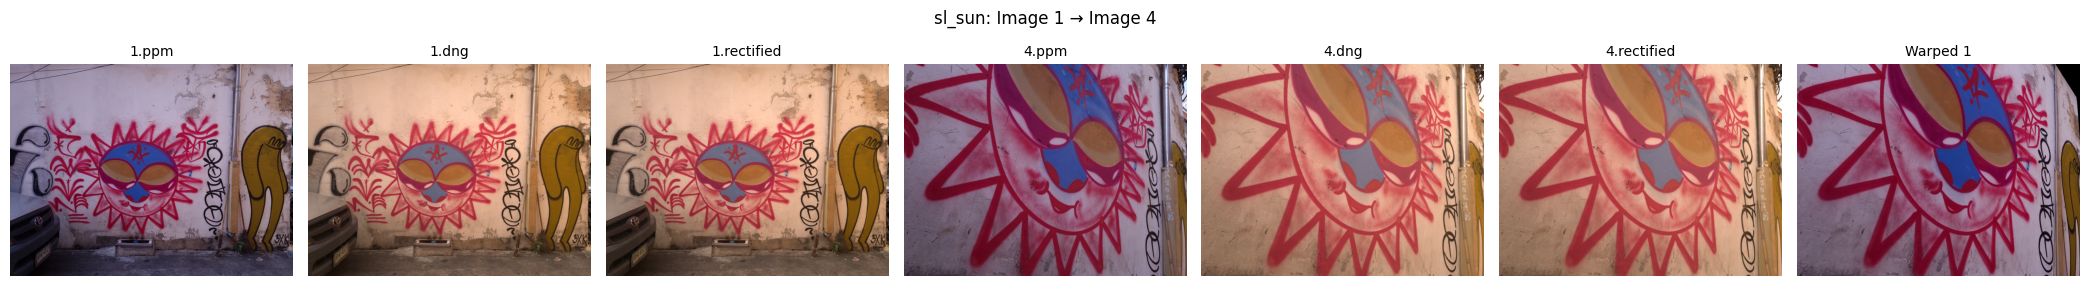

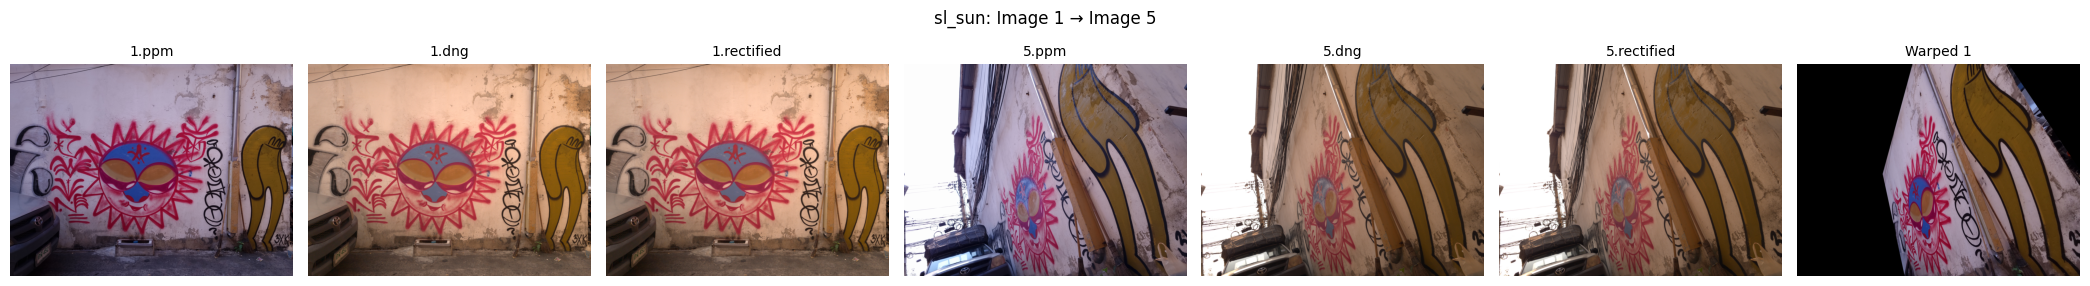

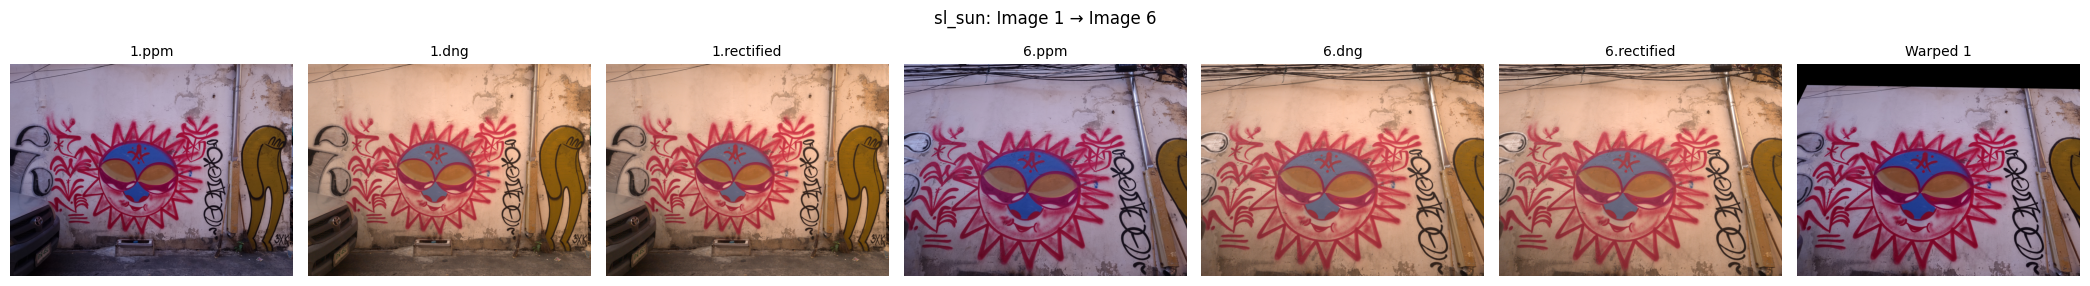

In [2]:
import os
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
import rawpy

def read_homography(file_path):
    with open(file_path, 'r') as f:
        H = np.array([float(num) for line in f for num in line.strip().split()]).reshape(3, 3)
    return H

def load_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_raw_image(raw_path):
    with rawpy.imread(raw_path) as raw:
        rgb = raw.postprocess()
    return rgb

def undistort_image(img, mtx, dist):
    h, w = img.shape[:2]
    new_mtx, _ = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 0)
    return cv2.undistort(img, mtx, dist, None, new_mtx)

def visualize_hpatches_sequence(seq_path, sequence_name, mtx, dist):
    img1_path = os.path.join(seq_path, "1.ppm")
    img1_dng_path = os.path.join(seq_path, "1.dng")

    try:
        img1 = load_image(img1_path)
        img1_dng = load_raw_image(img1_dng_path)
        img1_rect = undistort_image(img1_dng, mtx, dist)
    except Exception as e:
        print(f"Skipping {sequence_name}: error loading image 1 — {e}")
        return

    for k in range(2, 7):
        imgk_path = os.path.join(seq_path, f"{k}.ppm")
        imgk_dng_path = os.path.join(seq_path, f"{k}.dng")
        H_file = os.path.join(seq_path, f"H_1_{k}")

        if not os.path.isfile(imgk_path) or not os.path.isfile(H_file):
            print(f"Missing image or homography for k={k} in {sequence_name}")
            continue

        try:
            imgk = load_image(imgk_path)
            H = read_homography(H_file)
            warped_img1 = cv2.warpPerspective(img1, H, (imgk.shape[1], imgk.shape[0]))

            imgk_dng = load_raw_image(imgk_dng_path) if os.path.exists(imgk_dng_path) else None
            imgk_rect = undistort_image(imgk_dng, mtx, dist) if imgk_dng is not None else None
        except Exception as e:
            print(f"Error in {sequence_name}, image {k}: {e}")
            continue

        # Plot
        ncols = 7
        plt.figure(figsize=(3 * ncols, 3))
        plt.suptitle(f"{sequence_name}: Image 1 → Image {k}", fontsize=12)

        plt.subplot(1, ncols, 1)
        plt.imshow(img1)
        plt.title("1.ppm", fontsize=10)
        plt.axis('off')

        plt.subplot(1, ncols, 2)
        plt.imshow(img1_dng)
        plt.title("1.dng", fontsize=10)
        plt.axis('off')

        plt.subplot(1, ncols, 3)
        plt.imshow(img1_rect)
        plt.title("1.rectified", fontsize=10)
        plt.axis('off')

        plt.subplot(1, ncols, 4)
        plt.imshow(imgk)
        plt.title(f"{k}.ppm", fontsize=10)
        plt.axis('off')

        plt.subplot(1, ncols, 5)
        if imgk_dng is not None:
            plt.imshow(imgk_dng)
            plt.title(f"{k}.dng", fontsize=10)
        else:
            plt.text(0.5, 0.5, "Missing DNG", ha='center', va='center')
        plt.axis('off')

        plt.subplot(1, ncols, 6)
        if imgk_rect is not None:
            plt.imshow(imgk_rect)
            plt.title(f"{k}.rectified", fontsize=10)
        else:
            plt.text(0.5, 0.5, "Missing Rect", ha='center', va='center')
        plt.axis('off')

        plt.subplot(1, ncols, 7)
        plt.imshow(warped_img1)
        plt.title("Warped 1", fontsize=10)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

# === USAGE CONFIG ===
root_dir = "/home/boat/proxyISP/pytorch-superpoint/datasets/HPatches_s21fe_reordered"
regex_filter = r"sl_sun*"

cam_param = np.load("/home/boat/proxyISP/ProxyOpt/camera_parameters/s21fe_main_3000x4000/CalibrationMatrix_college_cpt.npz")
mtx = cam_param["Camera_matrix"]
dist = cam_param["distCoeff"]

pattern = re.compile(regex_filter)

for seq in sorted(os.listdir(root_dir)):
    if not pattern.match(seq):
        continue
    seq_path = os.path.join(root_dir, seq)
    if os.path.isdir(seq_path):
        visualize_hpatches_sequence(seq_path, seq, mtx, dist)
